In [2]:
#!/usr/bin/env -S grimaldi --kernel bento_kernel_default
# fmt: off

# No, you can't fire your way to a better company
Ten years ago, Meta had a reputation as a company with a high performance bar. Post-COVID, they decided to raise that bar, increasing the number of bad ratings they gave employees from [7% to 20%](https://finance.yahoo.com/news/meta-targets-more-underperformers-mid-150352697.html), in the name of intensity. However, anyone who has ever worked a job knows that you can't just fire a bunch of people without repurcussions. Morale tanked, and now Meta has a [retention problem](https://blog.pragmaticengineer.com/the-pulse-metas-self-inflicted-resignation-wave/).

As a scientist experiencing this, I thought, "I can model that." The model I built for performance management includes parameters for what skill distributions look like, how many people get fired, how much error there is in measuring performance, and how many people leave when you do it. I found that:
* In a world of no measurement error, and no "regrettable attrition," firing 20% of your people every year can give you +0.4 skill off a baseline of skill of 3.2.
* Adding in measurement errors for hiring and performance evaluations  halves this gain to only a +0.2 skill increase
* If aggressive performance management decreases morale such that people start leaving, the gains from performance management mostly evaporate. This is especially if the regrettable attrition is not random and biased towards high performers.
* Even modest training outperforms firing people
Given the diminishing returns to firing people, and the significant risk of increasing attrition, I would suggest most companies have performance quotas below 10%.

# The Setup
To simulate performance management at a company, I estimated every employees skill on a scale of 1-5. These skills could be drawn from three distributions: normal, uniform or skewed. In addition to employee's actual skill, when interviewing or evaluating employees, I added measurement error, with a default of 2 sigma for interviewing, and 1 sigma for evaluation. Finally, I simulated attrition as either random, or skewed towards higher performers, with a default of 10% attrition per year. This 10% attrition might be low for many companies where employees are job hopping, but is probably close to realistic for companies like Google or Microsoft.

# The initial simulations

# Stack-ranking performance-management simulation

## Purpose
Model the effect of stack-ranking (forced firing of bottom performers) on a company's mean skill over time, and compare it against alternative interventions (training, hiring bar changes). The simulation is designed to surface second-order effects: measurement noise, hiring quality, and attrition induced by a firing culture.

## Model overview

**Scale:** All true and measured skills are integers on **1–5** (1 = low performer, 5 = top performer).

**Candidate market (`skill_dist`):** Three pluggable distributions representing the external talent pool:
- `normal_skill(size, loc=3, scale=1)` — bell curve centered at 3
- `uniform_skill(size)` — equal weight across 1–5
- `skewed_skill(size, decay=0.6)` — geometrically decaying weights so rating 1 is the **plurality** (~47%), representing a market where most candidates are unqualified

**`simulate_company(...)` — one full simulation run:**

Cycle order each year:
1. **Review** — measure every employee's skill with Gaussian noise (`measure_sigma`), clipped to 1–5
2. **Fire** — the bottom `fire_pct` by measured rating get a **bad review**; anyone who has now collected `bad_ratings_to_fire` bad reviews **in a row** is fired (a non-bottom review resets the streak). With the default `bad_ratings_to_fire=1` this reduces to firing the bottom `fire_pct` outright.
3. **Voluntary attrition** — an additional `attrition_pct` quit (`attrition_mode='random'` or `'regret'` where higher-skill people are more likely to leave)
4. **Train** — retained employees gain `train_per_year` skill (`train_mode='flat'` or `'diminishing'` where gain ∝ headroom to 5)
5. **Backfill** — draw one large applicant pool and hire the **first N** who clear the `hiring_bar` on their measured interview score (pass/fail bar, not best-N selection)

**Key design decision:** The **founding team** is also assembled through the hiring bar (not drawn raw from `skill_dist`). So `skill_dist` represents the *external market*, and the company starts at year 0 already filtered — year-0 mean > market mean. This means `interview_sigma` shifts year-0 starting level, so the noise-sweep plot uses **absolute** skill (not gain vs. year 0) to avoid misleading orderings.

**Hiring mechanics:** `hire(n)` draws a single large applicant pool (sized from a cheap pass-rate probe, no rejection loop) and takes the **first N** who clear the bar. Because we take the first N who pass (not the best N), higher `interview_sigma` lets true-low-scorers through and screens out some genuine talent — realistically noisy. `hire()` also returns **how many candidates it had to interview** (the pool position of the n-th hire); `simulate_company` surfaces this per cycle as `company_interviews`, alongside `company_openings` (roles filled that cycle), so their ratio is the average interviews per open role.

## Key parameters and their defaults
| param | default | meaning |
|---|---|---|
| `measure_sigma` | 1 | std dev of review noise (in rating points) |
| `interview_sigma` | 0 | std dev of interview measurement noise |
| `fire_pct` | 0.10 | fraction given a bad review per cycle by stack rank |
| `bad_ratings_to_fire` | 1 | consecutive bad reviews before an employee is fired |
| `hiring_bar` | 3 | min measured interview score to get offer |
| `attrition_pct` | 0.0 | extra voluntary quit rate per cycle |
| `attrition_mode` | `'random'` | `'random'` or `'regret'` |
| `train_per_year` | 0.0 | skill gain per retained employee per cycle |
| `train_mode` | `'flat'` | `'flat'` or `'diminishing'` |
| `num_iter` | 10 | years to simulate |

`simulate_company` returns `(company_skills, company_measured_skill, company_interviews, company_openings)`, each a list of length `num_iter + 1` (index 0 = founding team).

## Plots in the notebook
1. **Distribution histograms** — sanity-check the three skill distributions (cell 4)
2. **Measurement error** — for each measured rating, shows the true-skill spread behind it (cells 7–8)
3. **Results table** — sweep over distributions × measure_sigma × interview_sigma, showing mean skill at years 1/3/5/10 (cells 11–12)
4. **Noise sweep** — 1×3 panels (one per distribution), lines are (measure, interview) noise combinations; plotted as **absolute** mean skill (cells 13–14)
5. **Firing-rate sweep** — normal dist, measure=1, interview=2; compare 5/10/20% fired; gain vs. year 0 (cells 15–16)
6. **Attrition comparison** — no attrition / +10% random / +10% regrettable; gain vs. year 0 (cells 17–18)
7. **Training vs. firing** — fire only / train only / both; gain vs. year 0 (cells 19–20)
8. **Trade-off sweeps** — three line plots: final skill vs. `fire_pct` by `attrition_pct`; total interviews vs. `hiring_bar` by distribution; final skill vs. `fire_pct` by firing threshold (cells 21–22)

## Colors
Okabe-Ito colorblind-friendly palette set globally via `plt.rcParams`. Order: blue `#0072B2`, orange `#E69F00`, black `#000000`, green `#009E73`, purple `#CC79A7`, sky `#56B4E9`, vermillion `#D55E00`.

## Key findings so far
- **Training dominates firing** (normal dist, m=1, i=2): training-only +0.2/yr → +1.62 gain; firing 10% → +0.91; both combined → +1.65 (firing adds almost nothing on top of training)
- **Regrettable attrition materially hurts**: +10% regrettable cuts year-10 gain from +0.91 to +0.58 (vs. +0.82 for random), because it directly cancels the benefit of retaining high performers
- **Higher firing rate helps but with diminishing returns**: 5% → +0.64, 10% → +0.91, 20% → +1.08
- **Noisy hiring bar is leaky**: with interview_sigma=2 and bar=3, skewed founding team only reaches mean 2.54 (vs. market mean 1.95) — many true-2s get through
- **A warning cycle (`bad_ratings_to_fire=2`) softens both skill gains and hiring churn**: fewer people cross the firing threshold each year, so year-10 skill rises less but far fewer candidates have to be interviewed to backfill
- **A tougher `hiring_bar` explodes hiring cost against a weak market**: total interviews grow steeply with the bar, and the skewed market is by far the most expensive to staff at a high bar

## Outstanding ideas / to-dos
- Implement unhappiness mechanisms that compound or target the top (flat morale penalty washes out under upward selection pressure):
  - **Review-signal degradation**: `measure_sigma` grows over time as people game ratings
  - **Multiplicative morale decay**: `skill *= (1 − p)` each cycle instead of flat subtraction
  - **Reputation damage**: `hiring_bar` degrades or the pass rate drops as employer brand worsens
  - **Collaboration penalty**: output = mean_skill − k·competition (individual skill up but team output down)
- Sweep `train_per_year` and `train_mode='diminishing'` to make the training comparison more rigorous
- Add absolute-skill version of firing-rate/attrition/training plots (currently gain-vs-year-0)
- Separate "real skill" from "perceived skill" (fixed per-employee measurement bias vs. fresh noise each cycle)
- Run multiple random seeds and show confidence bands on the trajectories

## Environment
- Python 3.13, `arbitrage-venv` at `~/.virtualenvs/arbitrage_venv/`
- Notebook executed and outputs embedded via `nbclient` (installed into the venv)
- No OneDrive sync during editing (turned off)


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from cycler import cycler

# Colorblind-friendly palette (Okabe-Ito), ordered blue / orange / black first.
CB_COLORS = ['#0072B2', '#E69F00', '#000000', '#009E73', '#CC79A7', '#56B4E9', '#D55E00']
plt.rcParams['axes.prop_cycle'] = cycler(color=CB_COLORS)

In [4]:
# --- Pluggable skill distributions: each returns ratings on a 1-5 scale ---

def normal_skill(size, loc=3, scale=1):
    """Bell-curve skill centered on a '3', rounded into 1-5 buckets."""
    return np.clip(np.random.normal(loc, scale, size).round(), 1, 5)


def uniform_skill(size):
    """Skill spread evenly across the 1-5 buckets."""
    return np.random.randint(1, 6, size).astype(float)


def skewed_skill(size, decay=0.6):
    """Right-skewed skill: most employees are unqualified.

    Per-rating probability decays geometrically, p(r) proportional to
    exp(-decay * (r - 1)), so rating 1 is the most common bucket (and at
    least as common as rating 2). Larger ``decay`` => more low performers.
    """
    ratings = np.arange(1, 6)
    weights = np.exp(-decay * (ratings - 1))
    weights /= weights.sum()
    return np.random.choice(ratings, size=size, p=weights).astype(float)


SKILL_DISTRIBUTIONS = {
    'normal': normal_skill,
    'uniform': uniform_skill,
    'skewed': skewed_skill,
}

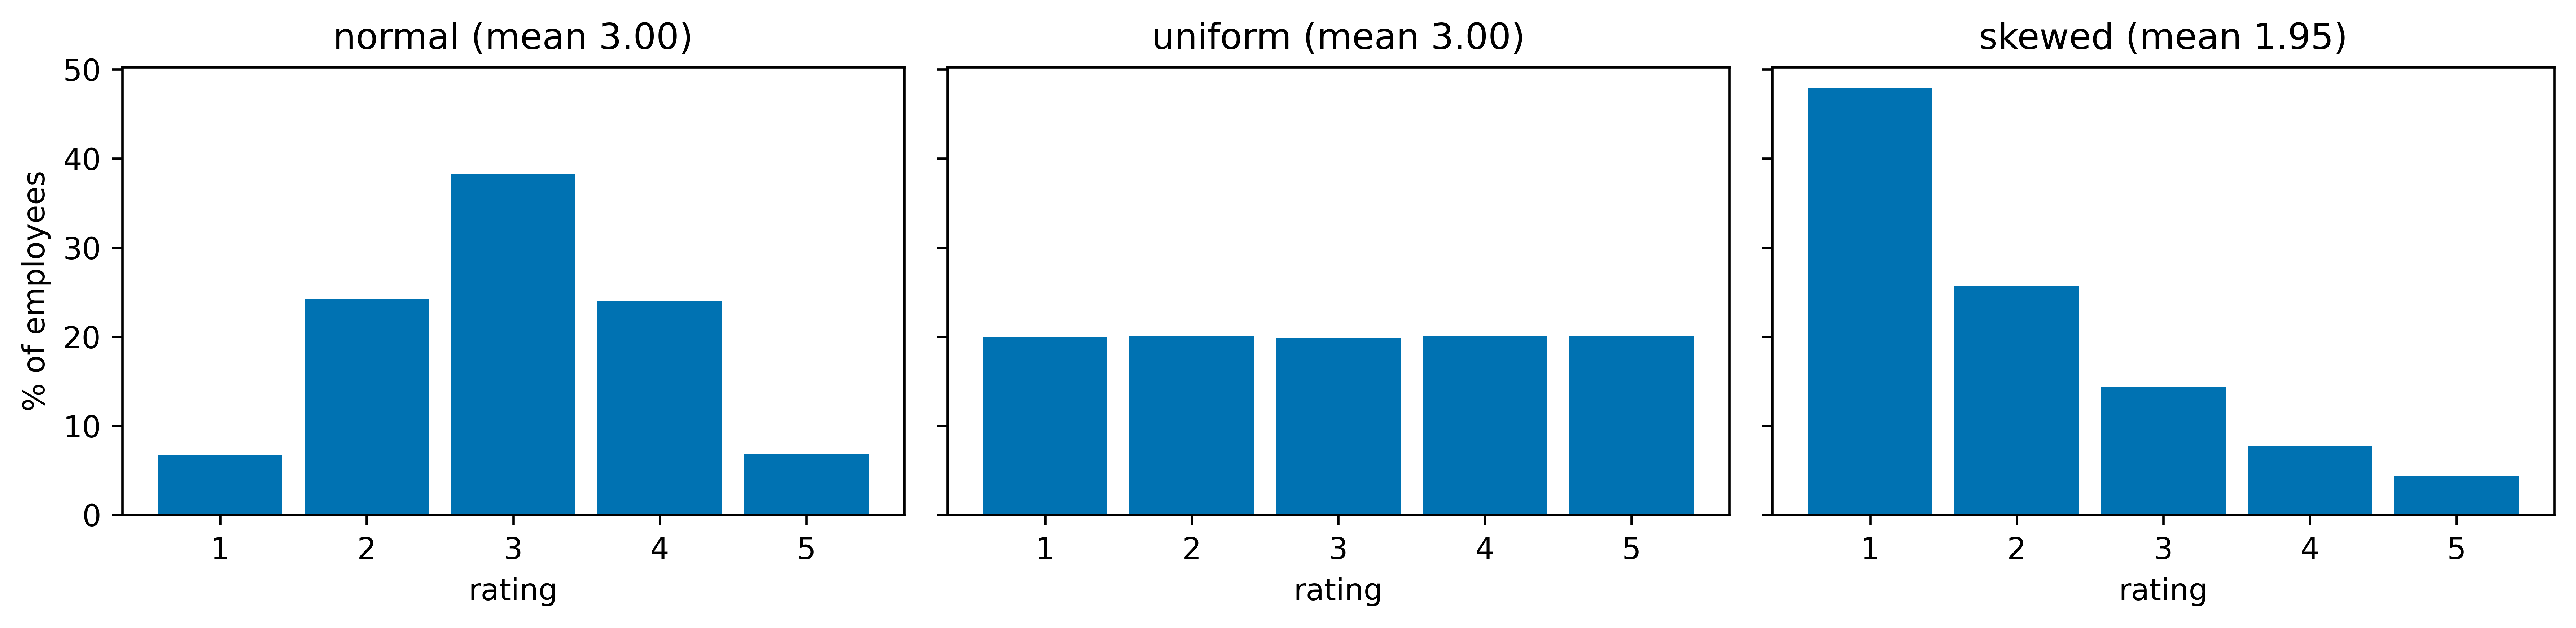

In [5]:
# Sanity-check the shape of each starting skill distribution
rating_bins = np.arange(0.5, 6.5, 1)
fig, axes = plt.subplots(1, 3, figsize=[12, 3], sharey=True, dpi = 600)
for ax, (name, dist) in zip(axes, SKILL_DISTRIBUTIONS.items()):
    sample = dist(100000)
    ax.hist(sample, bins=rating_bins, weights=np.full(sample.size, 100 / sample.size), rwidth=0.85)
    ax.set_title(f'{name} (mean {sample.mean():.2f})')
    ax.set_xlabel('rating')
    ax.set_xticks(range(1, 6))
axes[0].set_ylabel('% of employees')
plt.tight_layout()

## Measurement error
How true skill maps onto each *measured* rating, given review noise.

In [6]:
def plot_skill_measure(skill_dist=normal_skill, measure_sigma=1, company_size=100000):
    """For each measured rating bucket, show the distribution of true skill behind it."""
    skill = skill_dist(company_size)
    measured = np.clip((skill + np.random.normal(0, measure_sigma, company_size).round()), 1, 5)

    skill_pdf = pd.DataFrame({'skill': skill, 'measured_skill': measured})
    plt.subplots(1, figsize=[5, 4])
    for rating in range(1, 4):
        cur = skill_pdf.query('measured_skill == @rating')['skill'].value_counts().sort_index()
        if cur.empty:
            continue
        cur = 100 * cur / cur.sum()
        plt.plot(cur, marker='o', label=f'Real skill {rating}')
    plt.xlabel('Measured skill')
    plt.ylabel('% with this measured rating')
    plt.xticks(range(1, 6))
    plt.legend(frameon=False)

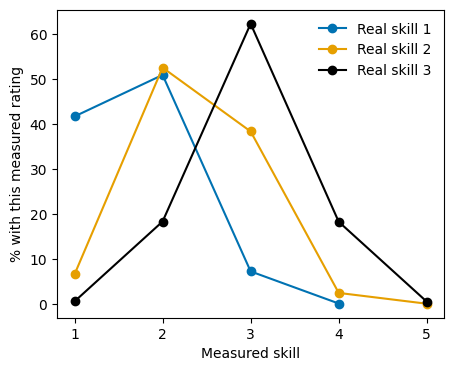

In [7]:
plot_skill_measure(measure_sigma=0.75)

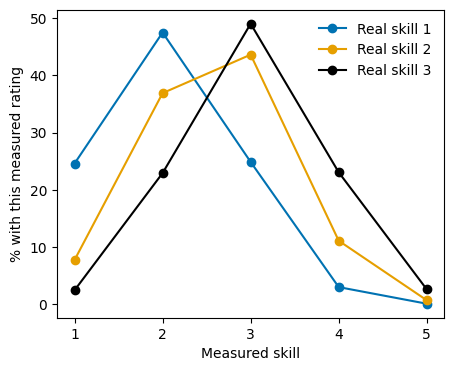

In [8]:
plot_skill_measure(measure_sigma=1.25)

## Company simulation
The founding team is hired through the same `hiring_bar` as everyone else (not drawn raw from the distribution). Each cycle then: review (measure) -> the bottom `fire_pct` receive a bad review, and anyone who has collected `bad_ratings_to_fire` bad reviews **in a row** is fired (default 1 = fired on the first bad review; a good review resets the streak) -> some survivors quit (`attrition_pct`) -> retained staff train (`train_per_year`) -> backfill every opening through the bar. Headcount is held constant; 10 cycles by default.

Backfilling no longer loops batch-by-batch: `hire(n)` draws a **single large applicant pool** (sized from a cheap pass-rate probe) and takes the **first `n`** who clear the bar. It also reports **how many candidates had to be interviewed** to fill those openings — the pool position of the n-th hire — which `simulate_company` returns per cycle as `company_interviews`.

In [9]:
def simulate_company(
    skill_dist=normal_skill,
    measure_sigma=1,
    interview_sigma=2,
    num_iter=10,
    company_size=100000,
    fire_pct=0.1,
    hiring_bar=3,
    attrition_pct=0.1,
    attrition_mode='random',
    train_per_year=0.0,
    train_mode='flat',
    bad_ratings_to_fire=1,
):
    """Simulate stack-ranking performance management on a 1-5 rating scale.

    The starting workforce is itself hired through the hiring bar (we do not
    draw it raw from ``skill_dist``). Each cycle then: review (measure) -> the
    bottom ``fire_pct`` get a bad review, and anyone who has now collected
    ``bad_ratings_to_fire`` bad reviews in a row is fired -> voluntary attrition
    among survivors -> train the retained employees -> backfill every opening.

    Args:
        skill_dist: callable(size) -> array of true skills on the 1-5 scale
            (the candidate-market distribution applicants are drawn from).
        measure_sigma: review noise added to true skill each cycle.
        interview_sigma: noise in measuring an applicant's skill at hiring.
        num_iter: number of review/fire/hire cycles to run.
        company_size: headcount, held constant across cycles.
        fire_pct: fraction handed a bad review each cycle (by measured rating).
        hiring_bar: minimum *measured* interview rating to get an offer. We hire
            the first applicants who clear the bar, not the absolute best.
        attrition_pct: extra fraction who quit each cycle (firing side effect).
        attrition_mode: 'random' (uniform) or 'regret' (higher skill more
            likely to leave -- losing your best people).
        train_per_year: skill each retained employee gains per cycle.
        train_mode: 'flat' (+train_per_year) or 'diminishing'
            (+train_per_year * (5 - skill), so gains shrink near the cap).
        bad_ratings_to_fire: number of consecutive bad reviews before an
            employee is actually fired (1 = fired the first time they land in
            the bottom fire_pct; 2 = they get one warning cycle to recover).

    Returns:
        (company_skills, company_measured_skill, company_interviews,
         company_openings): four lists of length ``num_iter + 1`` (index 0 =
            founding team). ``company_interviews[i]`` is how many candidates
            were interviewed to fill cycle i's openings, and
            ``company_openings[i]`` is how many roles that was -- so their ratio
            is the average number of interviews per open role that cycle.
    """
    def measure(skill, sigma):
        return np.clip((skill + np.random.normal(0, sigma, skill.size).round()), 1, 5)

    def hire(n):
        """Draw one big applicant pool and take the first n who clear the bar.

        Returns ``(hired_skills, n_interviewed)`` where ``n_interviewed`` is how
        many candidates we had to interview to fill the ``n`` openings -- i.e.
        the pool position of the n-th person to clear the bar. There is no
        rejection loop: a cheap probe estimates the pass rate so a single pool
        draw is virtually guaranteed to contain enough passers.
        """
        if n <= 0:
            return np.empty(0), 0
        # estimate how many candidates to use
        probe = measure(skill_dist(10000), interview_sigma)
        pass_rate = max((probe >= hiring_bar).mean(), 1e-3)
        pool_size = int(n / pass_rate * 1.5) + 1000

        # actually create a pool
        pool_skill = skill_dist(pool_size)
        passed_pos = np.flatnonzero(measure(pool_skill, interview_sigma) >= hiring_bar)
        hired = pool_skill[passed_pos[:n]]
        n_interviewed = int(passed_pos[n - 1]) + 1  # pool index of the n-th hire
        return hired, n_interviewed

    # The founding team is hired through the same bar as everyone else.
    founding, founding_interviews = hire(company_size)
    company_skills = [founding]
    company_measured_skill = [measure(founding, measure_sigma)]
    company_interviews = [founding_interviews]
    company_openings = [company_size]

    # Consecutive bad reviews each current employee has accumulated so far.
    strikes = np.zeros(company_size, dtype=int)

    n_fire = int(round(fire_pct * company_size))
    n_attrition = int(round(attrition_pct * company_size))

    for cur_iter in range(num_iter):
        cur_skill = company_skills[cur_iter]
        cur_measured = company_measured_skill[cur_iter]

        # 1. Stack ranking: the bottom n_fire by measured rating get a bad
        #    review this cycle; everyone else's streak resets. An employee is
        #    fired only once they hit bad_ratings_to_fire bad reviews in a row.
        flagged = np.zeros(cur_skill.size, dtype=bool)
        flagged[np.argsort(cur_measured, kind='stable')[:n_fire]] = True
        strikes = np.where(flagged, strikes + 1, 0)
        keep = strikes < bad_ratings_to_fire
        kept_skill = cur_skill[keep]
        kept_strikes = strikes[keep]

        # 2. Voluntary attrition among survivors (a side effect of the culture).
        n_quit = min(n_attrition, kept_skill.size)
        if n_quit:
            if attrition_mode == 'regret':
                p = kept_skill / kept_skill.sum()  # higher skill -> likelier to leave
                quit_idx = np.random.choice(kept_skill.size, size=n_quit, replace=False, p=p)
            else:
                quit_idx = np.random.choice(kept_skill.size, size=n_quit, replace=False)
            stay = np.ones(kept_skill.size, dtype=bool)
            stay[quit_idx] = False
            kept_skill = kept_skill[stay]
            kept_strikes = kept_strikes[stay]

        # 3. Training: retained employees improve.
        if train_per_year:
            if train_mode == 'diminishing':
                kept_skill = kept_skill + train_per_year * (5 - kept_skill)
            else:
                kept_skill = kept_skill + train_per_year
            kept_skill = np.clip(kept_skill, 1, 5)

        # 4. Backfill every opening through the hiring bar; new hires start
        #    with a clean slate (zero strikes).
        n_openings = company_size - kept_skill.size
        new_skill, n_interviewed = hire(n_openings)

        next_skill = np.concatenate([kept_skill, new_skill])
        strikes = np.concatenate([kept_strikes, np.zeros(new_skill.size, dtype=int)])
        company_skills.append(next_skill)
        company_measured_skill.append(measure(next_skill, measure_sigma))
        company_interviews.append(n_interviewed)
        company_openings.append(n_openings)

    return company_skills, company_measured_skill, company_interviews, company_openings

In [10]:
results_list = []
for dist_name, skill_dist in SKILL_DISTRIBUTIONS.items():
    for measure_sigma in (1, 2, 3):
        for interview_sigma in (0, 1, 2):
            cur_skills, _, _, _ = simulate_company(
                skill_dist=skill_dist,
                measure_sigma=measure_sigma,
                interview_sigma=interview_sigma,
            )
            skill_means = [np.mean(x) for x in cur_skills]
            results_list.append({
                'distribution': dist_name,
                'measure_sigma': measure_sigma,
                'interview_sigma': interview_sigma,
                'start_skill': skill_means[0],
                'year1_skill': skill_means[1],
                'year3_skill': skill_means[3],
                'year5_skill': skill_means[5],
                'year10_skill': skill_means[10],
            })

In [11]:
pd.DataFrame(results_list)

,distribution,measure_sigma,interview_sigma,start_skill,year1_skill,year3_skill,year5_skill,year10_skill
0,normal,1,0,3.54287,3.57863,3.63722,3.67928,3.73376
1,normal,1,1,3.43477,3.51651,3.61073,3.66424,3.72337
2,normal,1,2,3.30615,3.40776,3.52186,3.58012,3.64052
3,normal,2,0,3.54141,3.56659,3.59969,3.62257,3.65294
4,normal,2,1,3.43228,3.47400,3.53076,3.55687,3.59200
5,normal,2,2,3.30621,3.35745,3.42085,3.45428,3.49024
6,normal,3,0,3.54414,3.55749,3.57377,3.58435,3.59352
7,normal,3,1,3.43369,3.46077,3.48767,3.50061,3.50942
8,normal,3,2,3.30394,3.33403,3.36718,3.38451,3.39942
9,uniform,1,0,3.99988,4.07015,4.17914,4.25390,4.31073


## Skill over time, by distribution
One panel per starting distribution; within each panel we sweep the noise levels `(measure_sigma, interview_sigma)`. Plotted as **absolute** mean true skill (not gain vs. year 0): because the founding team is hired through the bar, `interview_sigma` shifts the year-0 starting level, so baselining to 0 would be misleading here.

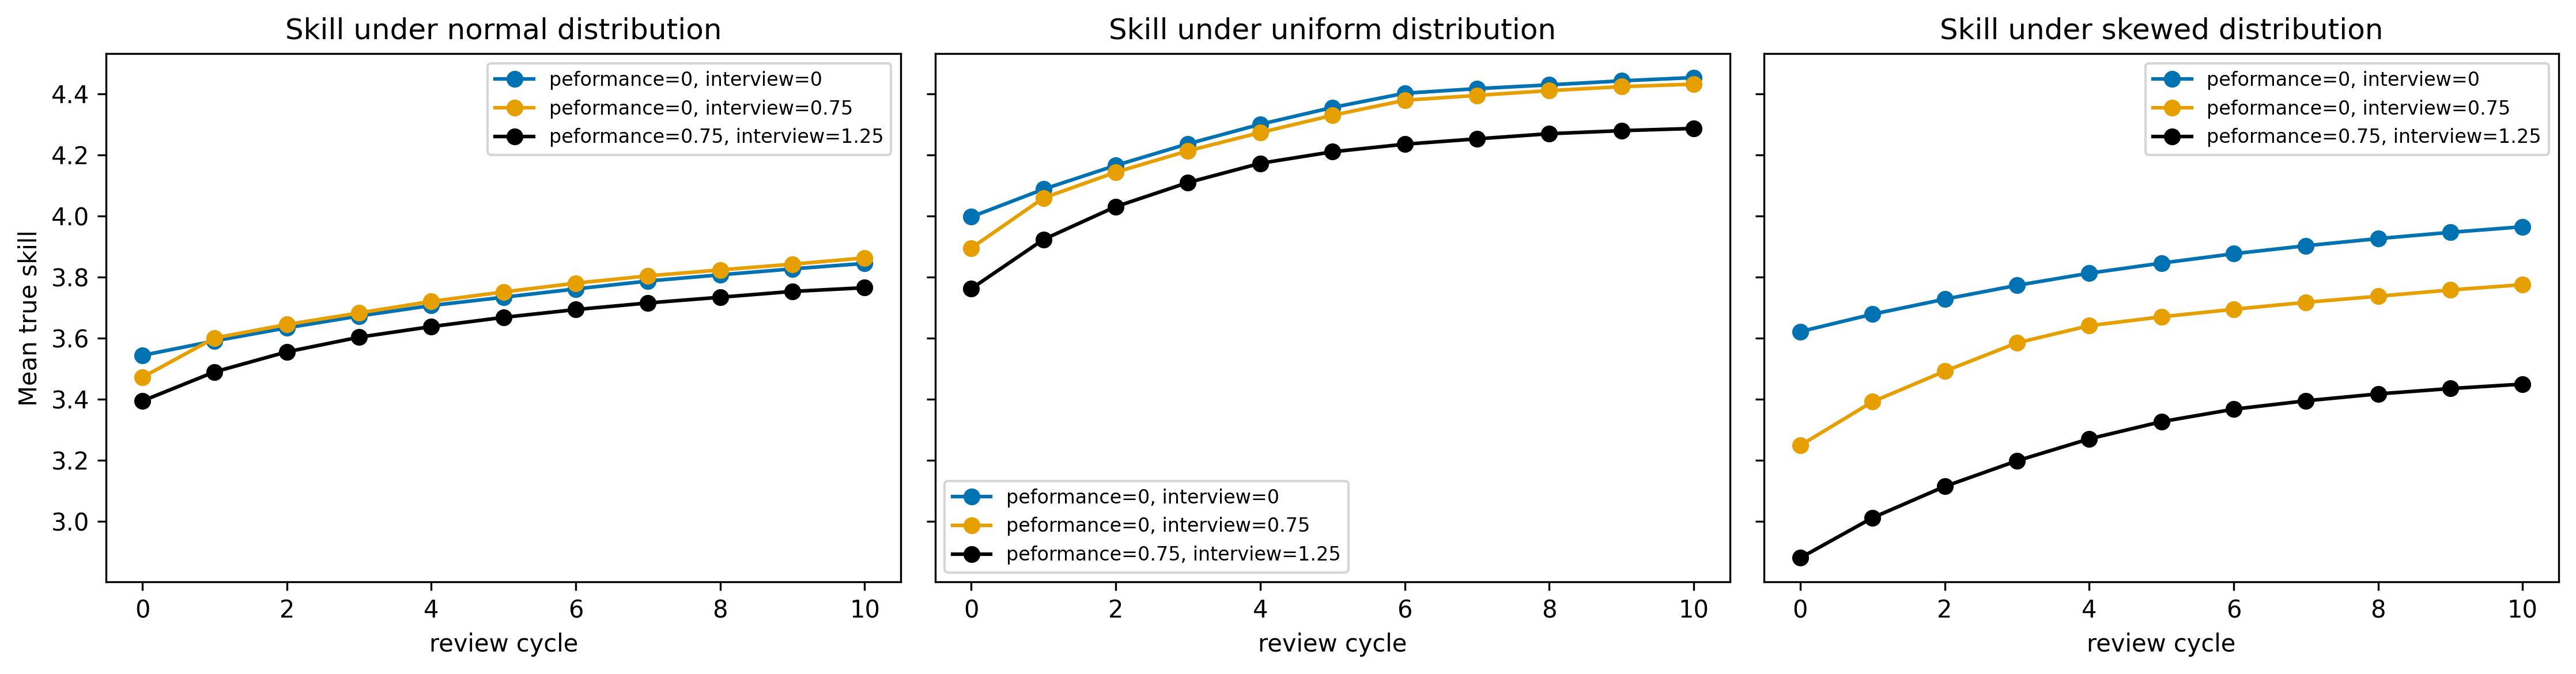

In [12]:
noise_sweep = [
    (0, 0),  # perfect reviews, perfect interviews
    (0, 0.75),  # perfect reviews, noisy interviews
    (0.75, 1.25),
]

fig, axes = plt.subplots(1, 3, figsize=[15, 4], sharey=True, dpi= 300)
for ax, (dist_name, skill_dist) in zip(axes, SKILL_DISTRIBUTIONS.items()):
    for m_sig, i_sig in noise_sweep:
        cur_skills, _, _, _ = simulate_company(
            skill_dist=skill_dist, measure_sigma=m_sig, interview_sigma=i_sig, num_iter=10
        )
        means = np.array([np.mean(x) for x in cur_skills])
        ax.plot(means, marker='o', label=f'peformance={m_sig}, interview={i_sig}')
    ax.set_title(f'Skill under {dist_name} distribution')
    ax.set_xlabel('review cycle')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Mean true skill')
plt.tight_layout()

## Normal distribution: effect of firing rate
Fixed `measure_sigma=1`, `interview_sigma=2`; comparing 5% / 10% / 20% stack-ranked out each cycle, again baselined to year 0.

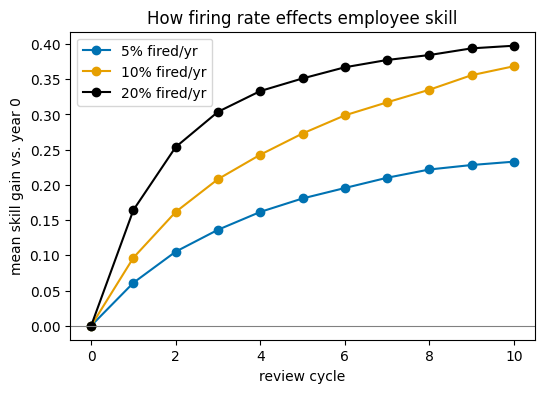

In [13]:
plt.subplots(1, figsize=[6, 4])
for fire_pct in (0.05, 0.10, 0.20):
    cur_skills, _, _, _ = simulate_company(
        skill_dist=normal_skill, measure_sigma=0.75, interview_sigma=1.25, fire_pct=fire_pct, num_iter=10
    )
    means = np.array([np.mean(x) for x in cur_skills])
    plt.plot(means - means[0], marker='o', label=f'{fire_pct:.0%} fired/yr')
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('review cycle')
plt.ylabel('mean skill gain vs. year 0')
plt.title('How firing rate effects employee skill')
plt.legend()

## Side effects of firing: voluntary attrition
A firing culture pushes people out the door beyond those formally cut. `attrition_pct` removes an extra slice of survivors each cycle -- either at **random** (general morale damage) or **regrettable** (higher-skill people, who have the most outside options, leave first). Compared on the normal distribution.

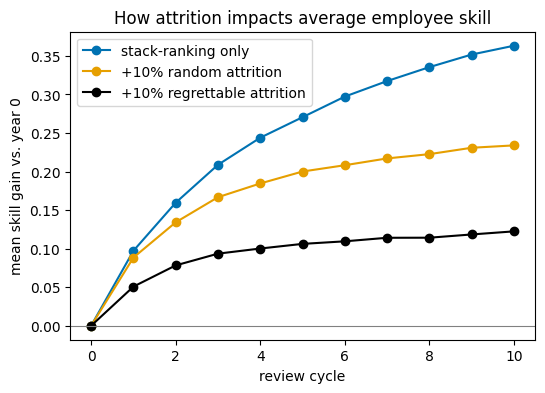

In [14]:
plt.subplots(1, figsize=[6, 4])
attrition_scenarios = {
    'stack-ranking only': dict(),
    '+10% random attrition': dict(attrition_pct=0.20, attrition_mode='random'),
    '+10% regrettable attrition': dict(attrition_pct=0.20, attrition_mode='regret'),
}
for label, kw in attrition_scenarios.items():
    cur_skills, _, _, _ = simulate_company(
        skill_dist=normal_skill, measure_sigma=0.75, interview_sigma=1.25, fire_pct=0.10, num_iter=10, **kw
    )
    means = np.array([np.mean(x) for x in cur_skills])
    plt.plot(means - means[0], marker='o', label=label)
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('review cycle')
plt.ylabel('mean skill gain vs. year 0')
plt.title('How attrition impacts average employee skill')
plt.legend()

## Training vs. firing
Instead of (or alongside) culling the bottom, just **improve the people you have**: each retained employee gains `train_per_year` skill per cycle. Compare pure stack-ranking, pure training (no firing), and both, on the normal distribution.

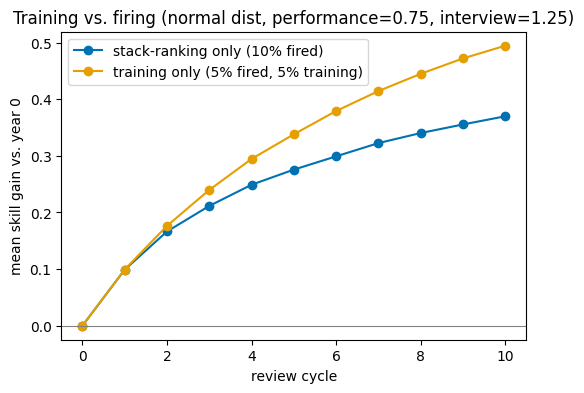

In [15]:
plt.subplots(1, figsize=[6, 4])
policy_scenarios = {
    'stack-ranking only (10% fired)': dict(fire_pct=0.10, train_per_year=0.0),
    'training only (5% fired, 5% training)': dict(fire_pct=0.05, train_per_year=0.05)
}
for label, kw in policy_scenarios.items():
    cur_skills, _, _, _ = simulate_company(
        skill_dist=normal_skill, measure_sigma=0.75, interview_sigma=1.25, num_iter=10, **kw
    )
    means = np.array([np.mean(x) for x in cur_skills])
    plt.plot(means - means[0], marker='o', label=label)
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('review cycle')
plt.ylabel('mean skill gain vs. year 0')
plt.title('Training vs. firing (normal dist, performance=0.75, interview=1.25)')
plt.legend()

## Trade-off sweeps
Three slices (normal dist unless noted, `company_size=20000` for speed).

- **Left — firing rate vs. attrition:** year-10 mean skill on the y-axis, `fire_pct` (5 / 10 / 20%) on the x-axis, one line per `attrition_pct` (5 / 10 / 20%, **regrettable**). Firing harder lifts skill; regrettable attrition drags every line down.
- **Middle — hiring cost vs. bar:** total candidates interviewed over the 10-year run (thousands) vs. `hiring_bar`, one line per candidate market (normal / uniform / skewed, `interview_sigma=0`). A tougher bar — especially against the skewed market — makes hiring dramatically more expensive.
- **Right — firing threshold:** year-10 mean skill vs. `fire_pct`, one line per `bad_ratings_to_fire` (1 vs. 2). Requiring two consecutive bad reviews before firing keeps more weak performers, so skill lands lower at every firing rate.

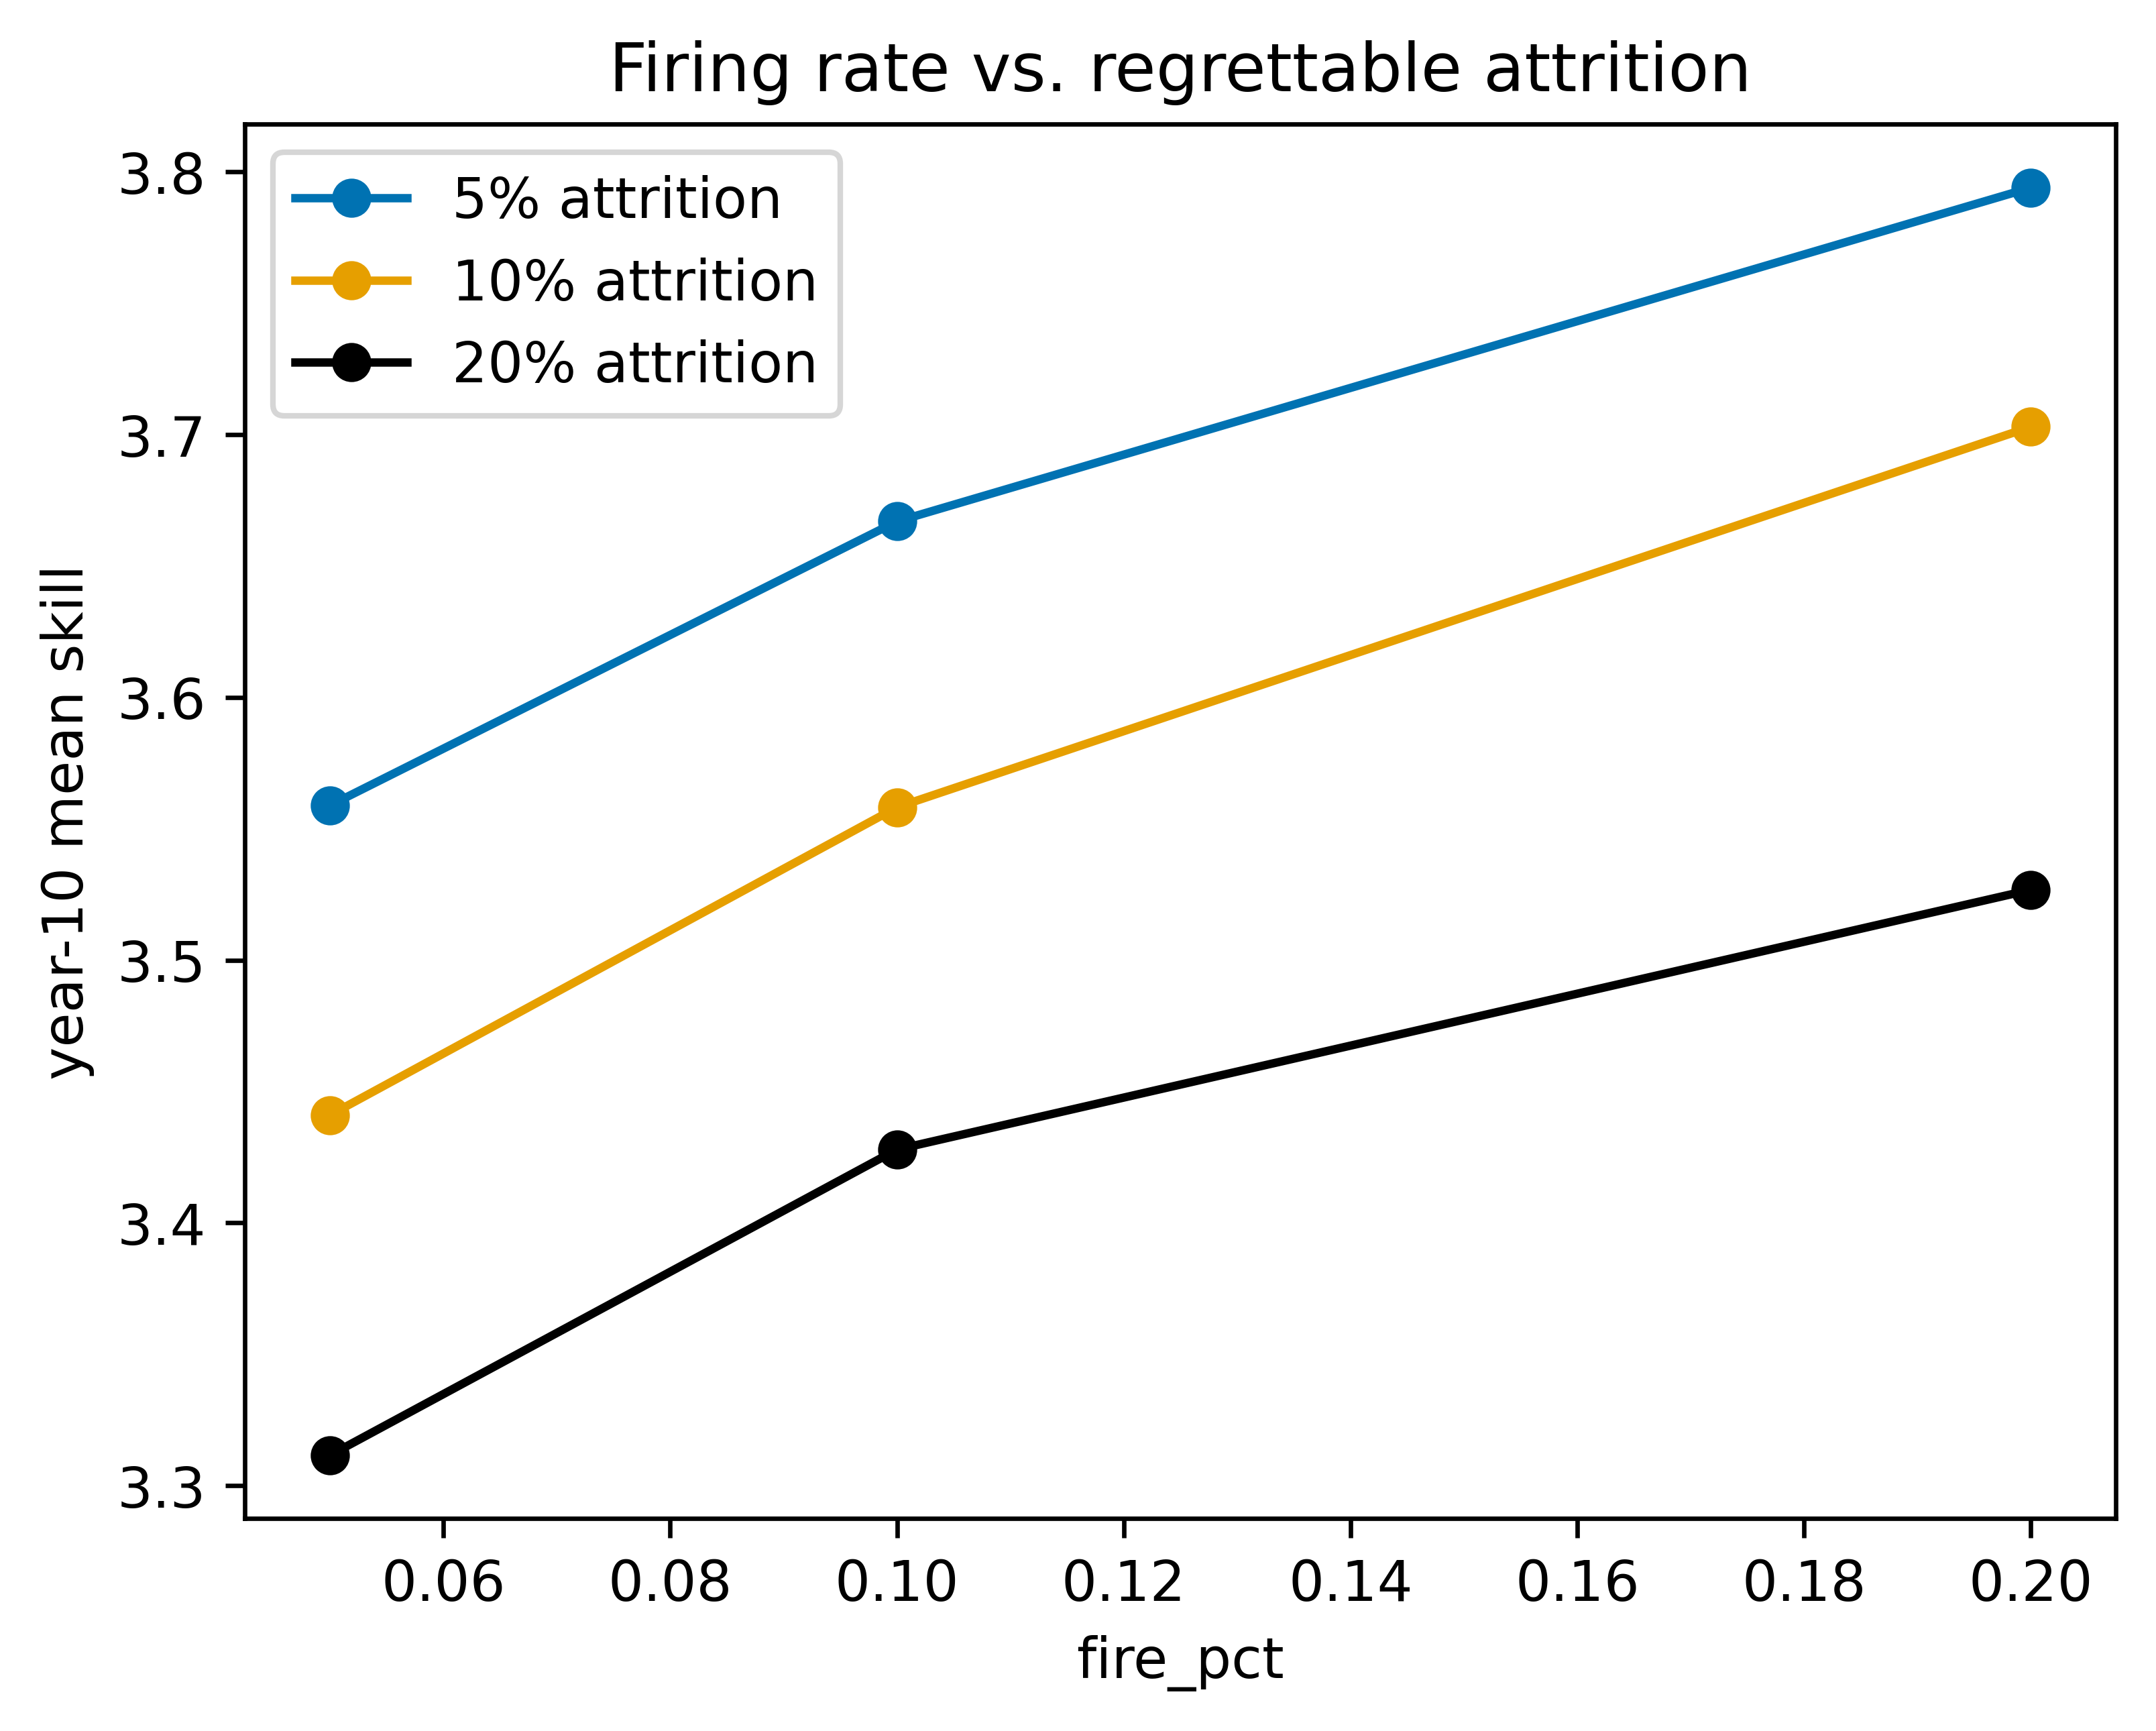

In [16]:
# --- Parameter trade-off sweeps (company_size=20000 for speed) ---
fig, axes = plt.subplots(1, 1, figsize=[6, 4.5], dpi = 600)
axes = [axes]
# LEFT: final skill vs. fire_pct, one line per attrition_pct (regrettable, so
# the trade-off has real tension -- aggressive firing pushes good people out).
for attrition_pct in (0.05, 0.10, 0.20):
    finals = []
    for fire_pct in (0.05, 0.10, 0.20):
        cur_skills, _, _, _ = simulate_company(
            skill_dist=normal_skill, measure_sigma=1, interview_sigma=2,
            fire_pct=fire_pct, attrition_pct=attrition_pct, attrition_mode='regret',
            num_iter=10, company_size=20000,
        )
        finals.append(np.mean(cur_skills[-1]))
    axes[0].plot([0.05, 0.10, 0.20], finals, marker='o', label=f'{attrition_pct:.0%} attrition')
axes[0].set(xlabel='fire_pct', ylabel='year-10 mean skill',
            title='Firing rate vs. regrettable attrition')
axes[0].legend()



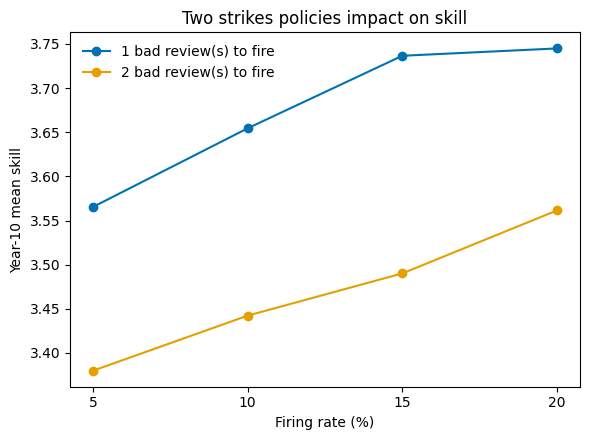

In [21]:

fig, axes = plt.subplots(1, 1, figsize=[6, 4.5])
axes=[axes]
# RIGHT: final skill vs. fire_pct, one line per firing threshold (how many
# consecutive bad reviews it takes to actually be fired).
for bad_ratings_to_fire in (1, 2):
    finals = []
    fires = np.array([0.05, 0.10, 0.15, 0.20])
    for fire_pct in fires:
        cur_skills, _, _, _ = simulate_company(
            skill_dist=normal_skill, measure_sigma=1, interview_sigma=2,
            fire_pct=fire_pct, bad_ratings_to_fire=bad_ratings_to_fire,
            num_iter=10, company_size=20000,
        )
        finals.append(np.mean(cur_skills[-1]))
    axes[0].plot(fires * 100, finals, marker='o', label=f'{bad_ratings_to_fire} bad review(s) to fire')
axes[0].set(xlabel='Firing rate (%)', ylabel='Year-10 mean skill',
            title='Two strikes policies impact on skill', xticks = fires * 100)
plt.tight_layout()
axes[0].legend(frameon=False)
